In [2]:
%pip install numpy
%pip install pillow
%pip install matplotlib
%pip install tifffile 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
from PIL import Image
import random
from typing import List
from itertools import permutations
import matplotlib.pyplot as plt
import tifffile
from pathlib import Path

### Rutas

In [4]:
base = Path().resolve().parent
carpeta_resultados = base / "Resultados"
ruta_imagen = base / "Imagenes" / "Mariposa.png"
ruta_cifrado = carpeta_resultados / "cifrado.tiff"
ruta_cifrado_png = carpeta_resultados / "cifrado_visual.png"
ruta_meta = carpeta_resultados / "cifrado_meta.txt"

### Funciones de imagen

In [5]:
# Funcion meramente cosmetica, basicamente para poder ver las imagenes con sus colores una vez obtenemos el RGB
def visualizar_canal_color(canal_img: Image.Image, color: str) -> Image.Image:
    color = color.upper()
    if color not in ["R", "G", "B"]:
        raise ValueError()

    arr = np.array(canal_img)
    zeros = np.zeros_like(arr)

    if color == "R":
        rgb = np.stack([arr, zeros, zeros], axis=2)
    elif color == "G":
        rgb = np.stack([zeros, arr, zeros], axis=2)
    else:
        rgb = np.stack([zeros, zeros, arr], axis=2)

    return Image.fromarray(rgb, mode="RGB")


def obtener_rgb(ruta_png: str):
    img = Image.open(ruta_png).convert("RGB")
    r_img, g_img, b_img = img.split()

    r = r_img  # (h, w)
    g = g_img  # (h, w)
    b = b_img  # (h, w)

    return r,g,b

### Funciones de llave

In [6]:
def generar_con_logistico(n: int, iteraciones_ignorar: int = 0, r: float = 3.99999):
    x = random.random()
    
    # Ignorar iteraciones 
    for _ in range(iteraciones_ignorar):
        x = r * x * (1 - x)
    
    # Generar los n valores 
    valores = []
    for _ in range(n):
        x = r * x * (1 - x)
        valores.append(x)
    
    return valores

def generar_llave(imagen_R, imagen_G, imagen_B, verbose=False):
    primer_fila_R = np.array(imagen_R)[0]
    primer_fila_G = np.array(imagen_G)[0]
    primer_fila_B = np.array(imagen_B)[0]
    
    primera_fila = []
    for i in range(len(primer_fila_R)):
        primera_fila.append(primer_fila_R[i])
        primera_fila.append(primer_fila_G[i])
        primera_fila.append(primer_fila_B[i])

    promedio = np.mean(primera_fila)
    parte_entera = int(promedio)
    K = sum(int(d) for d in str(parte_entera))
    
    secuencia_caotica_llave = generar_con_logistico(K, parte_entera)
    
    secuencia = []
    for x in secuencia_caotica_llave:
        x_abs = abs(x)
        grande = int(x_abs * 10**14)
        resto = x_abs - grande
        numero = resto % 24
        numero_final = int(numero) + 1  
        secuencia.append(numero_final)
    
    if K % 2 == 1:
        posicion_medio = (K + 1) // 2 - 1
    else:
        posicion_medio = K // 2 - 1
        
    valor_central = secuencia[posicion_medio]
    ultimo_bit = valor_central % 2
    
    if verbose:
        print(f"Promedio primera fila: {promedio:.2f}")
        print(f"Parte entera (iteradas a ignorar): {parte_entera}")
        print(f"K (valores a generar): {K}")
        print(f"Secuencia completa: {secuencia}")
        print(f"Posición media: {posicion_medio}")
        print(f"Valor central: {valor_central}")
        print(f"Valor central en binario: {bin(valor_central)}")
        print(f"Último bit: {ultimo_bit}")
        print(f"Dirección: {'derecha' if ultimo_bit == 1 else 'izquierda'}")
    
    if ultimo_bit == 0:
        matrices_finales = [secuencia[i] for i in range(posicion_medio)]
    else:
        matrices_finales = [secuencia[i] for i in range(posicion_medio + 1, K)]

    if verbose:
        print(f"Llave generada: {matrices_finales}")

    return matrices_finales

### Matrices

In [7]:
def generar_matrices_4x4():    
    sigma_x = np.array([[0, 1],
                        [1, 0]], dtype=complex)

    sigma_y = np.array([[0, -1j],
                        [1j,  0]], dtype=complex)

    sigma_z = np.array([[1,  0],
                        [0, -1]], dtype=complex)

    I = np.eye(2, dtype=complex)

    ops = [I, sigma_x, sigma_y, sigma_z]

    matrices_4x4 = []
    for M1, M2, M3, M4 in permutations(ops, 4):
        M = np.block([[M1, M2],
                      [M3, M4]])
        matrices_4x4.append(M)

    return matrices_4x4

def matrices_encriptacion(llave: List[int], matrices_rotacion):
    matrices_encript = []
    for item in llave:
        matrices_encript.append(matrices_rotacion[item % 24])
    return matrices_encript

### Cifrado

In [8]:
def obtener_rgb_como_bloques(R, G, B):
    def canal_a_bloques(canal_img):
        arr = np.array(canal_img).flatten().astype(float)
        pad = (4 - len(arr) % 4) % 4
        if pad:
            arr = np.concatenate([arr, np.zeros(pad)])
        return arr.reshape(4, -1)  # ← (4, N) 
    return canal_a_bloques(R), canal_a_bloques(G), canal_a_bloques(B)

def cifrar_canal(canal: np.ndarray, matrices_finales: list) -> np.ndarray:    
    resultado = canal.astype(complex)  
    for Mi in matrices_finales:
        resultado = Mi @ resultado  # ← (4,4) x (4,N) 
    return resultado

def cifrar_imagen(r, g, b, matrices_finales):
    Cr = cifrar_canal(r, matrices_finales)
    Cg = cifrar_canal(g, matrices_finales)
    Cb = cifrar_canal(b, matrices_finales)

    return Cr, Cg, Cb

### Cargar imagen y visualizar

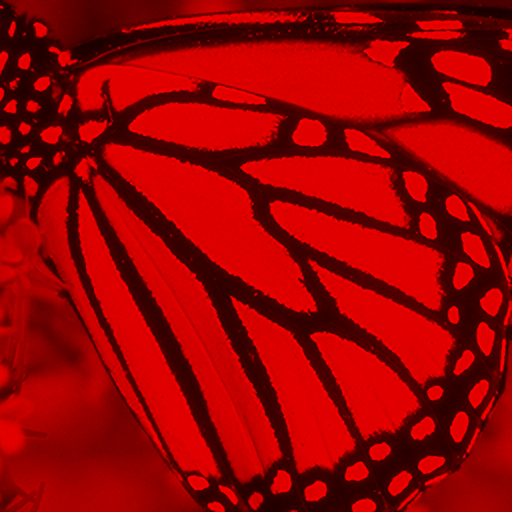

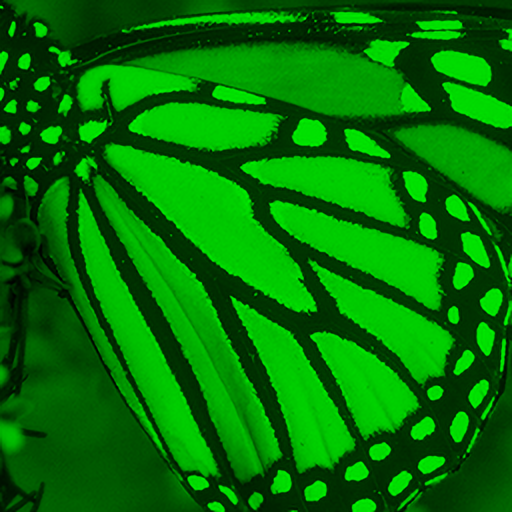

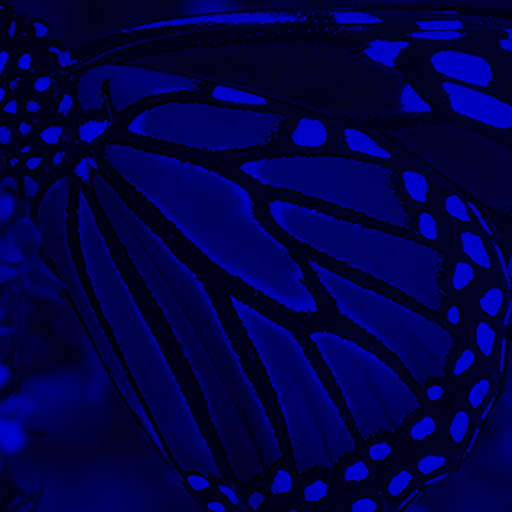

In [9]:
R, G, B = obtener_rgb(str(ruta_imagen))
h, w = R.height, R.width

display(visualizar_canal_color(R, 'R'))
display(visualizar_canal_color(G, 'G'))
display(visualizar_canal_color(B, 'B'))

Verificacion de la llave generada con atractor caotico

In [10]:
key = generar_llave(R, G, B, verbose=True)

Promedio primera fila: 76.59
Parte entera (iteradas a ignorar): 76
K (valores a generar): 13
Secuencia completa: [10, 3, 8, 23, 8, 10, 11, 21, 1, 21, 6, 7, 3]
Posición media: 6
Valor central: 11
Valor central en binario: 0b1011
Último bit: 1
Dirección: derecha
Llave generada: [21, 1, 21, 6, 7, 3]


### Cifrado y guardar

In [11]:
R_b, G_b, B_b = obtener_rgb_como_bloques(R, G, B)

matrices_rotadas = generar_matrices_4x4()

encriptacion = matrices_encriptacion(key, matrices_rotacion=matrices_rotadas)

c_r, c_g, c_b = cifrar_imagen(R_b, G_b, B_b, matrices_finales=encriptacion)

def canal_a_2d(canal_cifrado, h, w):
    flat = canal_cifrado.flatten()  
    needed = h * w
    if len(flat) < needed:
        flat = np.concatenate([flat, np.zeros(needed - len(flat), dtype=complex)])
    return flat[:needed].reshape(h, w) 

c_r_2d = canal_a_2d(c_r, h, w)
c_g_2d = canal_a_2d(c_g, h, w)
c_b_2d = canal_a_2d(c_b, h, w)

def guardar_cifrado_visual(c_r_2d, c_g_2d, c_b_2d, ruta_png):
    def normalizar(arr):
        arr = arr.real
        mn, mx = arr.min(), arr.max()
        if mx == mn:
            return np.zeros_like(arr, dtype=np.uint8)
        return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)

    r_vis = normalizar(c_r_2d)
    g_vis = normalizar(c_g_2d)
    b_vis = normalizar(c_b_2d)

    img_cifrada = Image.fromarray(np.stack([r_vis, g_vis, b_vis], axis=2), mode="RGB")
    img_cifrada.save(str(ruta_png))

def permutar_visual(arr2d, seed=42):
    rng = np.random.default_rng(seed)
    flat = arr2d.flatten()
    idx = rng.permutation(len(flat))
    return flat[idx].reshape(arr2d.shape)

guardar_cifrado_visual(
    permutar_visual(c_r_2d),
    permutar_visual(c_g_2d),
    permutar_visual(c_b_2d),
    ruta_cifrado_png
)

cifrado_stack = np.stack([
    c_r_2d.real.astype(np.float64),
    c_g_2d.real.astype(np.float64),
    c_b_2d.real.astype(np.float64),
    c_r_2d.imag.astype(np.float64),
    c_g_2d.imag.astype(np.float64),
    c_b_2d.imag.astype(np.float64),
], axis=0)

tifffile.imwrite(str(ruta_cifrado), cifrado_stack)

with open(str(ruta_meta), "w") as f:    
    f.write(f"key={key}\n")

print(cifrado_stack)

[[[ 260.  254.  282. ...  162.  -18. -200.]
  [ 260.  268.  278. ...  156. -136. -342.]
  [ 244.  290.  284. ...  100. -242. -452.]
  ...
  [ 350.  334.  332. ...  -34.   -4.  -24.]
  [ 342.  334.  356. ...  -60.   58.   74.]
  [ 344.  354.  394. ...  -82.   86.  192.]]

 [[ 600.  604.  640. ...  110.  -58. -236.]
  [ 602.  624.  644. ...  108. -172. -378.]
  [ 594.  646.  648. ...   64. -270. -488.]
  ...
  [  42.   38.   54. ...   52.   86.   64.]
  [  36.   42.   80. ...   30.  152.  170.]
  [  58.   78.  134. ...   18.  188.  292.]]

 [[ 248.  250.  282. ...  106.  -72. -258.]
  [ 244.  260.  278. ...  116. -176. -386.]
  [ 242.  296.  292. ...   86. -260. -480.]
  ...
  [ 152.  146.  154. ...  -18.   16.   -4.]
  [ 148.  148.  182. ...  -52.   76.   94.]
  [ 160.  172.  226. ...  -72.  104.  216.]]

 [[ 884.  866.  886. ...  102.  114.  116.]
  [ 872.  864.  862. ...  124.   76.   86.]
  [ 816.  858.  864. ...  108.   90.  104.]
  ...
  [ 414.  418.  416. ...  298.  308.  316.]
  

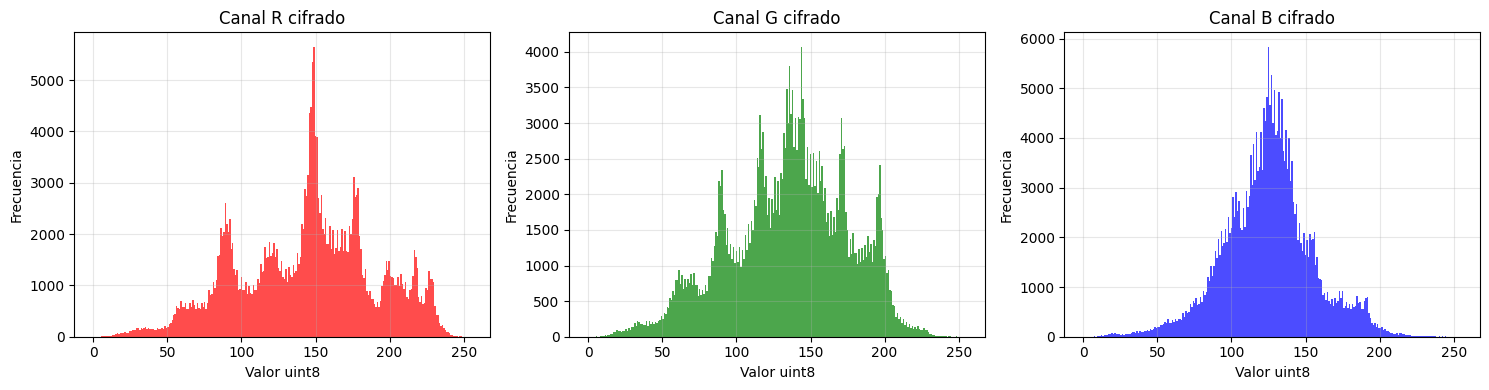

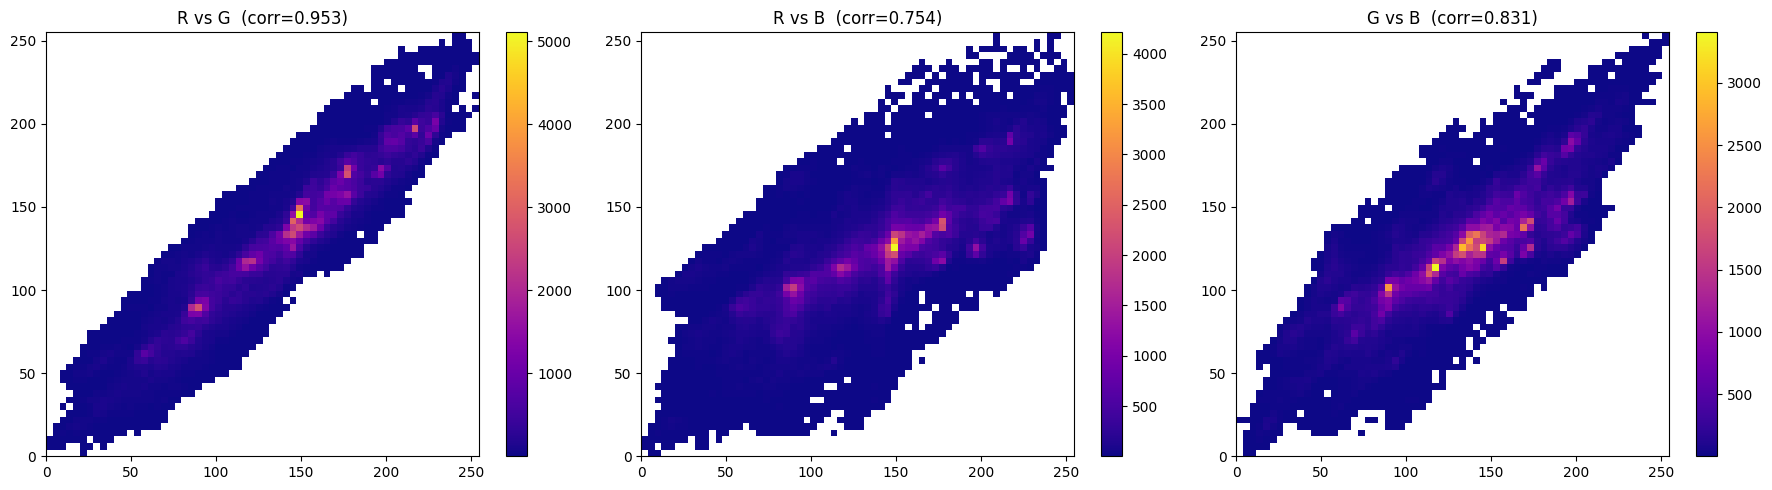

--- Estadísticas canales cifrados (float64) ---
R: min=-1144.00, max=1594.00, mean=413.60, std=493.17
G: min=-1184.00, max=1624.00, mean=311.41, std=443.58
B: min=-1162.00, max=1600.00, mean=196.66, std=324.92


In [12]:
def cargar_cifrado_tiff(ruta_cifrado):
    """
    Lee el TIFF de 6 capas: [R_real, G_real, B_real, R_imag, G_imag, B_imag]
    Devuelve parte real de cada canal como float64
    """
    img = tifffile.imread(ruta_cifrado).astype(np.float64)  # shape: (6, h, w)
    
    r_real = img[0]  # canal R parte real
    g_real = img[1]  # canal G parte real
    b_real = img[2]  # canal B parte real
    
    return r_real, g_real, b_real

def normalizar_canal(canal):
    """Normaliza a [0,255] uint8 para graficar histogramas"""
    mn, mx = np.nanmin(canal), np.nanmax(canal)
    if mx == mn:
        return np.zeros_like(canal, dtype=np.uint8)
    return np.clip(((canal - mn) / (mx - mn) * 255), 0, 255).astype(np.uint8)

# Cargar
r, g, b = cargar_cifrado_tiff(str(ruta_cifrado))  # usa la variable ya definida en bloque 1

# Normalizar para graficar
r8 = normalizar_canal(r)
g8 = normalizar_canal(g)
b8 = normalizar_canal(b)

r_flat = r8.flatten()
g_flat = g8.flatten()
b_flat = b8.flatten()

# --- Histogramas ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(r_flat, bins=256, range=(0,255), color='red',   alpha=0.7)
axes[0].set_title('Canal R cifrado')
axes[1].hist(g_flat, bins=256, range=(0,255), color='green', alpha=0.7)
axes[1].set_title('Canal G cifrado')
axes[2].hist(b_flat, bins=256, range=(0,255), color='blue',  alpha=0.7)
axes[2].set_title('Canal B cifrado')
for ax in axes:
    ax.set_xlabel('Valor uint8')
    ax.set_ylabel('Frecuencia')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Correlaciones entre canales ---
corr_rg = np.corrcoef(r_flat, g_flat)[0, 1]
corr_rb = np.corrcoef(r_flat, b_flat)[0, 1]
corr_gb = np.corrcoef(g_flat, b_flat)[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bins, cmap = 64, 'plasma'

h0 = axes[0].hist2d(r_flat, g_flat, bins=bins, range=[[0,255],[0,255]], cmap=cmap, cmin=1)
axes[0].set_title(f'R vs G  (corr={corr_rg:.3f})')
fig.colorbar(h0[3], ax=axes[0])

h1 = axes[1].hist2d(r_flat, b_flat, bins=bins, range=[[0,255],[0,255]], cmap=cmap, cmin=1)
axes[1].set_title(f'R vs B  (corr={corr_rb:.3f})')
fig.colorbar(h1[3], ax=axes[1])

h2 = axes[2].hist2d(g_flat, b_flat, bins=bins, range=[[0,255],[0,255]], cmap=cmap, cmin=1)
axes[2].set_title(f'G vs B  (corr={corr_gb:.3f})')
fig.colorbar(h2[3], ax=axes[2])

plt.tight_layout()
plt.show()

# --- Estadísticas float64 originales (antes de normalizar) ---
print("--- Estadísticas canales cifrados (float64) ---")
for nombre, canal in [('R', r), ('G', g), ('B', b)]:
    limpio = canal[np.isfinite(canal)]
    print(f"{nombre}: min={limpio.min():.2f}, max={limpio.max():.2f}, "
          f"mean={limpio.mean():.2f}, std={limpio.std():.2f}")